In [1]:
!pip install imbalanced-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
from sklearn.metrics import (classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, roc_auc_score, recall_score, precision_score, f1_score)

from imblearn.metrics import classification_report_imbalanced
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier

RS = 42


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Zadanie 1.1 – Pobranie danych i EDA

In [2]:
dataset = fetch_openml(data_id=40536, as_frame=True, parser='auto')
df = dataset.frame.copy()
df['match'] = pd.to_numeric(df['match'], errors='coerce').fillna(0).astype(int)
print(df.shape)
df['match'].value_counts()

(8378, 121)


match
0    6998
1    1380
Name: count, dtype: int64

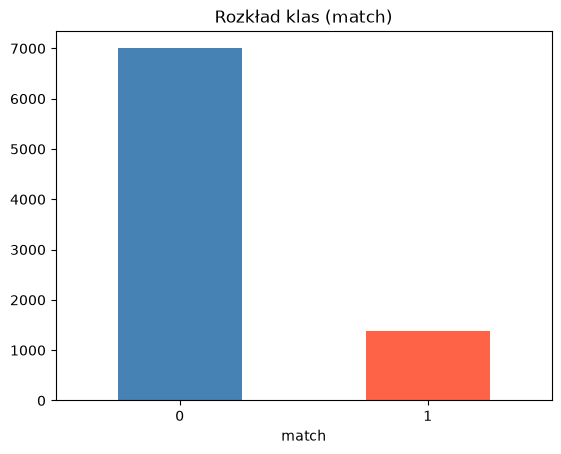

In [3]:
df['match'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Rozkład klas (match)'); plt.xticks(rotation=0); plt.show()

## Zadanie 1.2 – Przygotowanie danych

In [ ]:
drop_patterns = ['dec','like','prob','met','_2','_3']
id_cols = ['iid','id','idg','condtn','wave','round','position','positin1','order','partner','pid']
drop_cols = [c for c in df.columns if any(p in c for p in drop_patterns) and c != 'match']
drop_cols += [c for c in id_cols if c in df.columns]

df_clean = df.drop(columns=drop_cols, errors='ignore')

feat_cols = [c for c in df_clean.columns if c != 'match']
for c in feat_cols:
    df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce')
df_clean = df_clean.loc[:, df_clean.isnull().mean() < 0.7]
feat_cols = [c for c in df_clean.columns if c != 'match']
print(f'Cechy: {len(feat_cols)}, próbki: {len(df_clean)}')

Cechy: 56, próbki: 8378


In [ ]:
profile_cols = [c for c in ['gender','age','attr1_1','sinc1_1','intel1_1','fun1_1','amb1_1'] if c in df_clean.columns]
df_clean = df_clean.copy()
df_clean['fp'] = df_clean[profile_cols].fillna(-999).round(0).astype(str).apply('_'.join, axis=1)

train_idx, test_idx = [], []
np.random.seed(RS)
for _, g in df_clean.groupby('fp'):
    idx = g.index.tolist()
    np.random.shuffle(idx)
    if len(idx) > 5:
        test_idx.extend(idx[:5]); train_idx.extend(idx[5:])
    else:
        train_idx.extend(idx)

df_tr, df_te = df_clean.loc[train_idx], df_clean.loc[test_idx]
test_fp = df_te['fp']

X_tr_raw, y_tr = df_tr[feat_cols], df_tr['match'].values
X_te_raw, y_te = df_te[feat_cols], df_te['match'].values
print(f'Train: {X_tr_raw.shape}, Test: {X_te_raw.shape}')
print(f'Klasy train: {np.bincount(y_tr)}, test: {np.bincount(y_te)}')

Train: (8258, 56), Test: (120, 56)
Klasy train: [6899 1359], test: [99 21]


## Zadanie 1.3 – Model bazowy

In [ ]:
imp = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_tr = scaler.fit_transform(imp.fit_transform(X_tr_raw))
X_te = scaler.transform(imp.transform(X_te_raw))

cols = list(feat_cols)
pairs = [('attr1_1','attr2_1'),('sinc1_1','sinc2_1'),('intel1_1','intel2_1'),('fun1_1','fun2_1')]
for a, b in pairs:
    if a in cols and b in cols:
        ia, ib = cols.index(a), cols.index(b)
        diff = (X_tr[:,ia] - X_tr[:,ib]).reshape(-1,1)
        X_tr = np.hstack([X_tr, diff])
        diff_te = (X_te[:,ia] - X_te[:,ib]).reshape(-1,1)
        X_te = np.hstack([X_te, diff_te])

print(f'Liczba cech: {X_tr.shape[1]}')

Liczba cech: 56


In [ ]:
y_maj = np.zeros(len(y_te), dtype=int)
y_rnd = np.random.choice([0,1], len(y_te), p=np.bincount(y_tr)/len(y_tr))
print('=== Większościowy ==='); print(classification_report(y_te, y_maj, zero_division=0))
print('=== Losowy ===');        print(classification_report(y_te, y_rnd, zero_division=0))

=== Większościowy ===
              precision    recall  f1-score   support

           0       0.82      1.00      0.90        99
           1       0.00      0.00      0.00        21

    accuracy                           0.82       120
   macro avg       0.41      0.50      0.45       120
weighted avg       0.68      0.82      0.75       120

=== Losowy ===
              precision    recall  f1-score   support

           0       0.83      0.86      0.84        99
           1       0.18      0.14      0.16        21

    accuracy                           0.73       120
   macro avg       0.50      0.50      0.50       120
weighted avg       0.71      0.73      0.72       120



In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=RS)
lr.fit(X_tr, y_tr)
y_prob_lr = lr.predict_proba(X_te)[:,1]
print('=== Regresja logistyczna ===')
print(classification_report_imbalanced(y_te, lr.predict(X_te)))

=== Regresja logistyczna ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.85      0.98      0.19      0.91      0.43      0.20        99
          1       0.67      0.19      0.98      0.30      0.43      0.17        21

avg / total       0.82      0.84      0.33      0.80      0.43      0.20       120



## Zadanie 1.4 – Resampling + t-SNE

In [9]:
smote     = SMOTE(random_state=RS)
rus_smote = ImbPipeline([('u', RandomUnderSampler(sampling_strategy=0.3, random_state=RS)),
                          ('o', SMOTE(random_state=RS))])
smote_enn = SMOTEENN(random_state=RS)

X_sm, y_sm = smote.fit_resample(X_tr, y_tr)
X_rs, y_rs = rus_smote.fit_resample(X_tr, y_tr)
X_se, y_se = smote_enn.fit_resample(X_tr, y_tr)

for n, y_ in [('Oryginał', y_tr),('SMOTE', y_sm),('RUS+SMOTE', y_rs),('SMOTE+ENN', y_se)]:
    print(f'{n}: {np.bincount(y_)}')

Oryginał: [6899 1359]
SMOTE: [6899 6899]
RUS+SMOTE: [4530 4530]
SMOTE+ENN: [4115 6587]


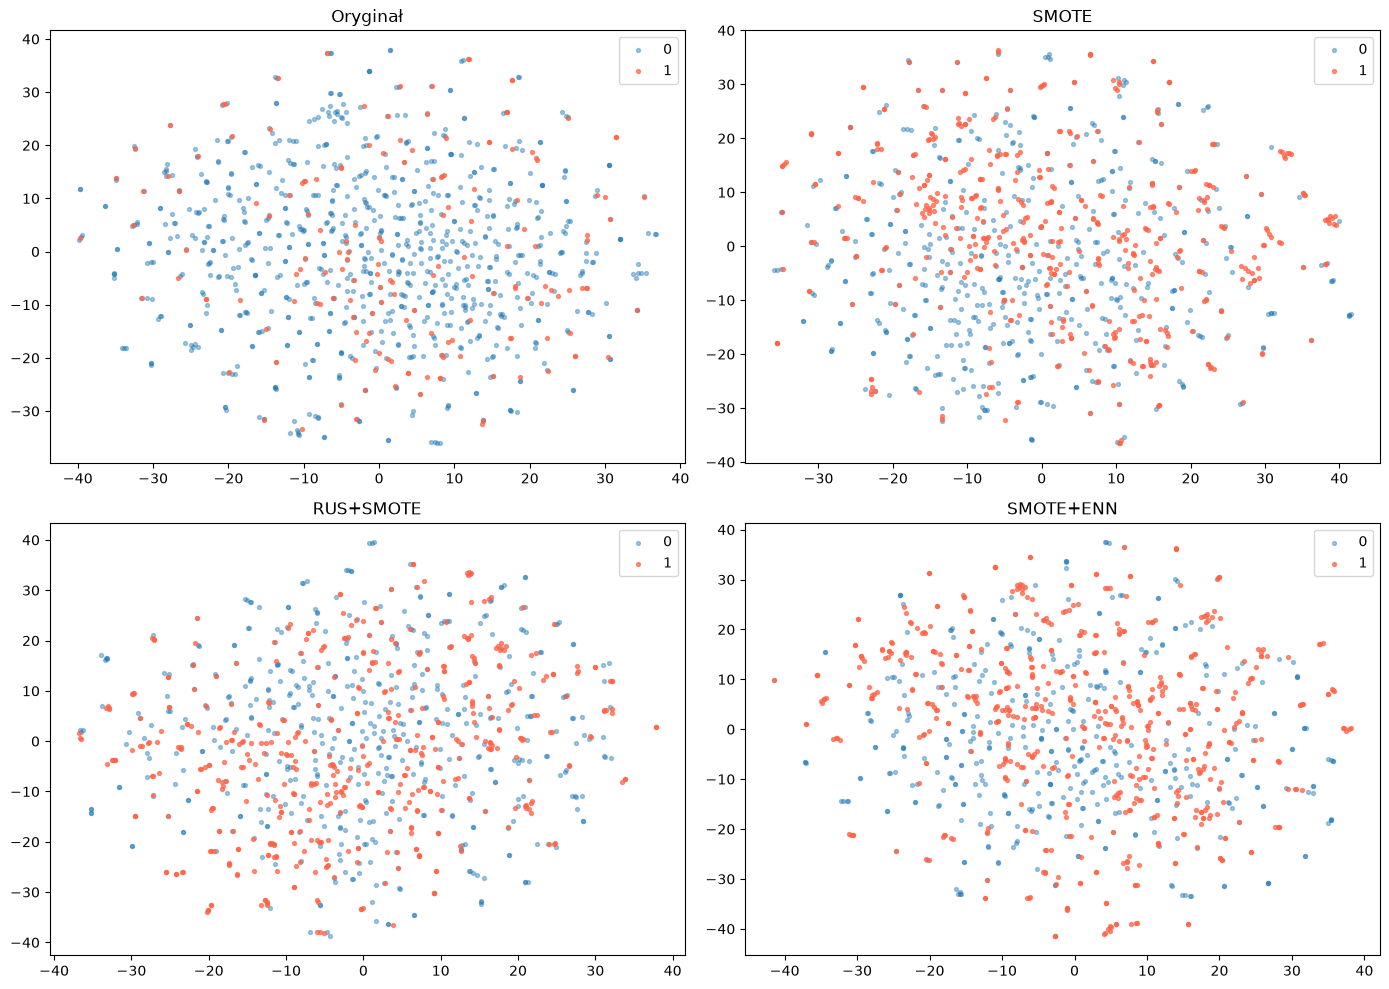

In [ ]:
tsne = TSNE(n_components=2, random_state=RS, perplexity=30, max_iter=500)
N = 1000

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (title, X_, y_) in zip(axes.flatten(),
        [('Oryginał', X_tr, y_tr), ('SMOTE', X_sm, y_sm),
         ('RUS+SMOTE', X_rs, y_rs), ('SMOTE+ENN', X_se, y_se)]):
    idx = np.random.choice(len(X_), min(N, len(X_)), replace=False)
    Xt = tsne.fit_transform(X_[idx]); yt = y_[idx]
    ax.scatter(Xt[yt==0,0], Xt[yt==0,1], s=8, alpha=0.4, label='0')
    ax.scatter(Xt[yt==1,0], Xt[yt==1,1], s=8, alpha=0.7, c='tomato', label='1')
    ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
for name, Xr, yr in [('Oryginał', X_tr, y_tr), ('SMOTE', X_sm, y_sm),
                      ('RUS+SMOTE', X_rs, y_rs), ('SMOTE+ENN', X_se, y_se)]:
    m = LogisticRegression(max_iter=1000, random_state=RS).fit(Xr, yr)
    print(f'--- {name} ---')
    print(classification_report_imbalanced(y_te, m.predict(X_te)))

--- Oryginał ---
                   pre       rec       spe        f1       geo       iba       sup

          0       0.85      0.98      0.19      0.91      0.43      0.20        99
          1       0.67      0.19      0.98      0.30      0.43      0.17        21

avg / total       0.82      0.84      0.33      0.80      0.43      0.20       120

--- SMOTE ---
                   pre       rec       spe        f1       geo       iba       sup

          0       0.91      0.80      0.62      0.85      0.70      0.50        99
          1       0.39      0.62      0.80      0.48      0.70      0.49        21

avg / total       0.82      0.77      0.65      0.79      0.70      0.50       120

--- RUS+SMOTE ---
                   pre       rec       spe        f1       geo       iba       sup

          0       0.90      0.81      0.57      0.85      0.68      0.47        99
          1       0.39      0.57      0.81      0.46      0.68      0.45        21

avg / total       0.81      0.

## Zadanie 1.5 – Ensemble + krzywe ROC/PR

In [12]:
models_ens = [
    ('RF balanced',  RandomForestClassifier(100, class_weight='balanced', random_state=RS, n_jobs=-1)),
    ('BalancedRF',   BalancedRandomForestClassifier(100, random_state=RS, replacement=True, n_jobs=-1)),
    ('EasyEnsemble', EasyEnsembleClassifier(10, random_state=RS, n_jobs=-1)),
]

probs_ens = {'LR': y_prob_lr}
for name, m in models_ens:
    m.fit(X_tr, y_tr)
    probs_ens[name] = m.predict_proba(X_te)[:,1]
    print(f'--- {name} ---')
    print(classification_report_imbalanced(y_te, m.predict(X_te)))

--- RF balanced ---
                   pre       rec       spe        f1       geo       iba       sup

          0       0.88      0.98      0.38      0.93      0.61      0.40        99
          1       0.80      0.38      0.98      0.52      0.61      0.35        21

avg / total       0.87      0.88      0.49      0.86      0.61      0.39       120

--- BalancedRF ---
                   pre       rec       spe        f1       geo       iba       sup

          0       0.89      0.89      0.48      0.89      0.65      0.44        99
          1       0.48      0.48      0.89      0.48      0.65      0.41        21

avg / total       0.82      0.82      0.55      0.82      0.65      0.43       120

--- EasyEnsemble ---
                   pre       rec       spe        f1       geo       iba       sup

          0       0.91      0.78      0.62      0.84      0.69      0.49        99
          1       0.37      0.62      0.78      0.46      0.69      0.47        21

avg / total       0

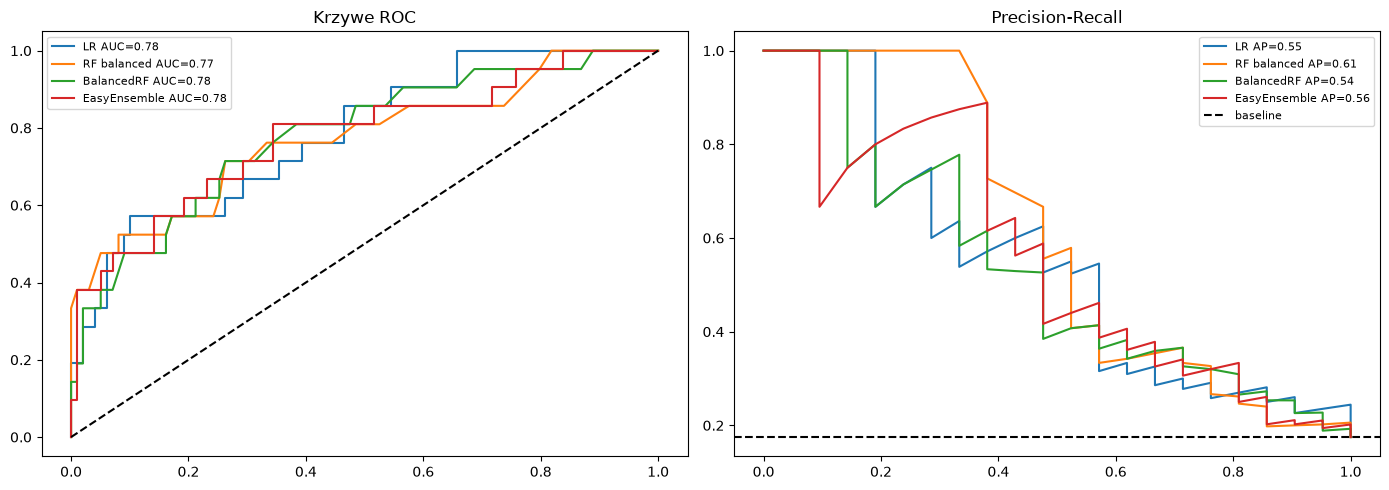

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for name, p in probs_ens.items():
    fpr, tpr, _ = roc_curve(y_te, p)
    ax1.plot(fpr, tpr, label=f'{name} AUC={auc(fpr,tpr):.2f}')
    pr, rc, _ = precision_recall_curve(y_te, p)
    ax2.plot(rc, pr, label=f'{name} AP={average_precision_score(y_te,p):.2f}')
ax1.plot([0,1],[0,1],'k--'); ax1.set_title('Krzywe ROC'); ax1.legend(fontsize=8)
ax2.axhline(y_te.mean(), color='k', linestyle='--', label='baseline')
ax2.set_title('Precision-Recall'); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Zadanie 2.1 – Precision@K i MRR

In [ ]:
y_prob_best = probs_ens['BalancedRF']

def precision_at_k(y_true, y_prob, user_ids, k=5):
    df_e = pd.DataFrame({'y': y_true, 'p': y_prob, 'u': user_ids})
    vals = [g.sort_values('p',ascending=False).head(k)['y'].sum()/k
            for _, g in df_e.groupby('u') if g['y'].sum() > 0]
    return np.mean(vals)

def mrr(y_true, y_prob, user_ids):
    df_e = pd.DataFrame({'y': y_true, 'p': y_prob, 'u': user_ids})
    vals = []
    for _, g in df_e.groupby('u'):
        if g['y'].sum() == 0: continue
        ranks = g.sort_values('p',ascending=False).reset_index(drop=True)['y']
        first = ranks[ranks==1].index[0] + 1
        vals.append(1/first)
    return np.mean(vals)

print(f"Precision@5: {precision_at_k(y_te, y_prob_best, test_fp.values):.3f}")
print(f"MRR:         {mrr(y_te, y_prob_best, test_fp.values):.3f}")

Precision@5: 0.300
MRR:         0.756


## Zadanie 2.2 – Model Romantyczny (max recall)

In [15]:
thresh_rom = np.percentile(y_prob_best, 20)
y_pred_rom = (y_prob_best >= thresh_rom).astype(int)
print(f'Próg: {thresh_rom:.3f}')
print(classification_report(y_te, y_pred_rom, zero_division=0))

Próg: 0.148
              precision    recall  f1-score   support

           0       0.96      0.23      0.37        99
           1       0.21      0.95      0.34        21

    accuracy                           0.36       120
   macro avg       0.58      0.59      0.36       120
weighted avg       0.83      0.36      0.37       120



## Zadanie 2.3 – Model Biznesowy (macierz kosztów)

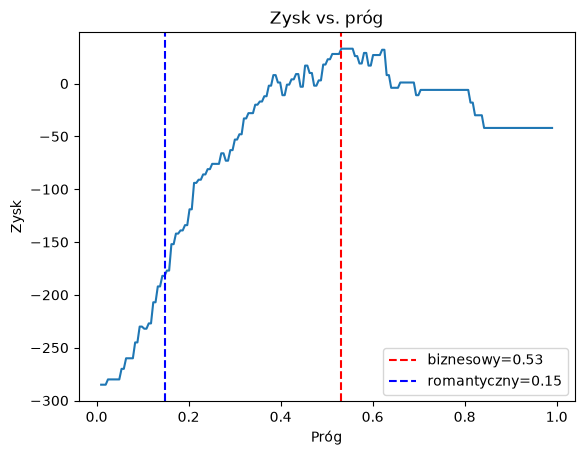

Próg biznesowy: 0.532
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        99
           1       0.53      0.48      0.50        21

    accuracy                           0.83       120
   macro avg       0.71      0.69      0.70       120
weighted avg       0.83      0.83      0.83       120



In [ ]:
def get_profit(y_true, y_pred, tp=10, tn=0, fp=-5, fn=-2):
    cm = confusion_matrix(y_true, y_pred).ravel()
    TN,FP,FN,TP = cm
    return TP*tp + TN*tn + FP*fp + FN*fn

thresholds = np.linspace(0.01, 0.99, 200)
profits = [get_profit(y_te, (y_prob_best >= t).astype(int)) for t in thresholds]

thresh_biz = thresholds[np.argmax(profits)]
y_pred_biz = (y_prob_best >= thresh_biz).astype(int)

plt.plot(thresholds, profits)
plt.axvline(thresh_biz, c='r', linestyle='--', label=f'biznesowy={thresh_biz:.2f}')
plt.axvline(thresh_rom, c='b', linestyle='--', label=f'romantyczny={thresh_rom:.2f}')
plt.xlabel('Próg'); plt.ylabel('Zysk'); plt.title('Zysk vs. próg')
plt.legend(); plt.show()

print(f'Próg biznesowy: {thresh_biz:.3f}')
print(classification_report(y_te, y_pred_biz, zero_division=0))

## Zadanie 2.4 – Porównanie modeli

In [17]:
rows = []
for name, y_pred in [('Romantyczny', y_pred_rom), ('Biznesowy', y_pred_biz)]:
    TN,FP,FN,TP = confusion_matrix(y_te, y_pred).ravel()
    rows.append({
        'Model':     name,
        'Recall':    recall_score(y_te, y_pred, zero_division=0),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'F1':        f1_score(y_te, y_pred, zero_division=0),
        'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
        'Zysk':      get_profit(y_te, y_pred)
    })

pd.DataFrame(rows).set_index('Model').round(3)

,Recall,Precision,F1,TP,FP,FN,TN,Zysk
Model,,,,,,,,
Romantyczny,0.952,0.208,0.342,20,76,1,23,-182
Biznesowy,0.476,0.526,0.500,10,9,11,90,33
